<a href="https://colab.research.google.com/github/lizzie-qing/Avatar-Demo/blob/main/cropped_faces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install dlib opencv-python pandas numpy


In [5]:
import zipfile
from pathlib import Path

BASE_DIR = Path("/content/poster_face_analysis")
INPUT_DIR = BASE_DIR / "02_cropped_faces"
CHECK_DIR = BASE_DIR / "03_landmark_check"
OUTPUT_DIR = BASE_DIR / "04_features"

INPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECK_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

zip_path = "/content/cropped_faces_JP_all.zip"  # 这里改成你的zip文件名

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(INPUT_DIR)

image_files = list(INPUT_DIR.rglob("*"))
print("解压完成")
print("文件数量：", len(image_files))
print("前10个文件：")
for f in image_files[:10]:
    print(f)

解压完成
文件数量： 203
前10个文件：
/content/poster_face_analysis/02_cropped_faces/JP_DIS_025_face.png
/content/poster_face_analysis/02_cropped_faces/JP_PUB_005_face.png
/content/poster_face_analysis/02_cropped_faces/JP_DIS_019_face.png
/content/poster_face_analysis/02_cropped_faces/JP_MED_018_face.png
/content/poster_face_analysis/02_cropped_faces/JP_MED_023_face.png
/content/poster_face_analysis/02_cropped_faces/JP_MED_016_face.png
/content/poster_face_analysis/02_cropped_faces/JP_DIS_006_face.png
/content/poster_face_analysis/02_cropped_faces/JP_DIS_008_face.png
/content/poster_face_analysis/02_cropped_faces/JP_DIS_020_face.png
/content/poster_face_analysis/02_cropped_faces/JP_PUB_018_face.png


In [6]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bzip2 -d shape_predictor_68_face_landmarks.dat.bz2


--2026-06-04 11:12:01--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-06-04 11:12:01--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  52.4MB/s    in 1.2s    

2026-06-04 11:12:03 (52.4 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]



In [7]:
import cv2
import dlib
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path("/content/poster_face_analysis")

INPUT_DIR = BASE_DIR / "02_cropped_faces"
CHECK_DIR = BASE_DIR / "03_landmark_check"
OUTPUT_DIR = BASE_DIR / "04_features"

MODEL_PATH = Path("/content/shape_predictor_68_face_landmarks.dat")

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(str(MODEL_PATH))

def shape_to_np(shape, dtype="int"):
    coords = np.zeros((68, 2), dtype=dtype)
    for i in range(68):
        coords[i] = (shape.part(i).x, shape.part(i).y)
    return coords

def draw_landmarks(image, landmarks):
    output = image.copy()
    for i, (x, y) in enumerate(landmarks):
        cv2.circle(output, (x, y), 2, (0, 0, 255), -1)
        cv2.putText(
            output,
            str(i + 1),
            (x + 2, y - 2),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.3,
            (255, 0, 0),
            1,
            cv2.LINE_AA
        )
    return output

def choose_main_face(faces):
    if len(faces) == 0:
        return None
    return max(faces, key=lambda rect: rect.width() * rect.height())

image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
image_files = [
    f for f in INPUT_DIR.rglob("*")
    if f.suffix.lower() in image_extensions
]

landmark_rows = []
log_rows = []

print(f"找到 {len(image_files)} 张图片，开始 dlib 检测...")

for image_path in sorted(image_files):
    filename = image_path.name
    poster_id = image_path.stem.replace("_face", "")

    image = cv2.imread(str(image_path))

    if image is None:
        log_rows.append({
            "poster_id": poster_id,
            "filename": filename,
            "status": "failed",
            "num_faces": 0,
            "problem": "cannot_read_image"
        })
        print(f"{filename}: cannot read")
        continue

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = detector(gray, 1)
    num_faces = len(faces)

    if num_faces == 0:
        log_rows.append({
            "poster_id": poster_id,
            "filename": filename,
            "status": "failed",
            "num_faces": 0,
            "problem": "no_face_detected"
        })
        print(f"{filename}: failed")
        continue

    main_face = choose_main_face(faces)
    shape = predictor(gray, main_face)
    landmarks = shape_to_np(shape)

    row = {
        "poster_id": poster_id,
        "filename": filename,
        "scene": poster_id.split("_")[1] if "_" in poster_id else "",
        "num_faces_detected": num_faces,
        "image_width": image.shape[1],
        "image_height": image.shape[0],
        "face_left": main_face.left(),
        "face_top": main_face.top(),
        "face_right": main_face.right(),
        "face_bottom": main_face.bottom(),
    }

    for i, (x, y) in enumerate(landmarks, start=1):
        row[f"x{i}"] = x
        row[f"y{i}"] = y

    landmark_rows.append(row)

    log_rows.append({
        "poster_id": poster_id,
        "filename": filename,
        "scene": poster_id.split("_")[1] if "_" in poster_id else "",
        "status": "success",
        "num_faces": num_faces,
        "problem": ""
    })

    checked_image = draw_landmarks(image, landmarks)
    output_check_path = CHECK_DIR / f"{poster_id}_landmark_check.png"
    cv2.imwrite(str(output_check_path), checked_image)

    print(f"{filename}: success, faces={num_faces}")

landmarks_df = pd.DataFrame(landmark_rows)
log_df = pd.DataFrame(log_rows)

landmarks_csv = OUTPUT_DIR / "poster_dlib_landmarks_JP_all.csv"
log_csv = OUTPUT_DIR / "poster_dlib_detection_log_JP_all.csv"

landmarks_df.to_csv(landmarks_csv, index=False, encoding="utf-8-sig")
log_df.to_csv(log_csv, index=False, encoding="utf-8-sig")

print("\n完成")
print("总图片数:", len(image_files))
print("成功检测:", (log_df["status"] == "success").sum())
print("检测失败:", (log_df["status"] == "failed").sum())
print("landmark csv:", landmarks_csv)
print("log csv:", log_csv)

找到 202 张图片，开始 dlib 检测...
JP_DIS_001_face.png: success, faces=1
JP_DIS_002_face.png: success, faces=1
JP_DIS_003_face.png: success, faces=1
JP_DIS_004_face.png: success, faces=1
JP_DIS_005face.png: success, faces=1
JP_DIS_006_face.png: success, faces=1
JP_DIS_007_face.png: success, faces=1
JP_DIS_008_face.png: success, faces=1
JP_DIS_009_face.png: success, faces=1
JP_DIS_010_face.png: success, faces=1
JP_DIS_011_face.png: success, faces=1
JP_DIS_012_face.png: success, faces=1
JP_DIS_013_face.png: success, faces=1
JP_DIS_014_face.png: success, faces=1
JP_DIS_015_face.png: success, faces=1
JP_DIS_016_face.png: success, faces=1
JP_DIS_017_face.png: success, faces=1
JP_DIS_018_face.png: success, faces=1
JP_DIS_019_face.png: success, faces=1
JP_DIS_020_face.png: success, faces=1
JP_DIS_021_face.png: success, faces=1
JP_DIS_022_face.png: success, faces=1
JP_DIS_023_face.png: success, faces=1
JP_DIS_024_face.png: success, faces=1
JP_DIS_025_face.png: success, faces=1
JP_DIS_026_face.png: succe

In [8]:
log_df.groupby(["scene", "status"]).size().reset_index(name="count")


,scene,status,count
0,DIS,success,31
1,MED,success,37
2,PUB,success,33


In [9]:
log_df[log_df["status"] == "failed"]

,poster_id,filename,scene,status,num_faces,problem
101,._JP_DIS_001,._JP_DIS_001_face.png,NaN,failed,0,cannot_read_image
102,._JP_DIS_002,._JP_DIS_002_face.png,NaN,failed,0,cannot_read_image
103,._JP_DIS_003,._JP_DIS_003_face.png,NaN,failed,0,cannot_read_image
104,._JP_DIS_004,._JP_DIS_004_face.png,NaN,failed,0,cannot_read_image
105,._JP_DIS_005face,._JP_DIS_005face.png,NaN,failed,0,cannot_read_image
...,...,...,...,...,...,...
197,._JP_PUB_029,._JP_PUB_029_face.png,NaN,failed,0,cannot_read_image
198,._JP_PUB_030,._JP_PUB_030_face.png,NaN,failed,0,cannot_read_image
199,._JP_PUB_031,._JP_PUB_031_face.png,NaN,failed,0,cannot_read_image
200,._JP_PUB_032,._JP_PUB_032_face.png,NaN,failed,0,cannot_read_image


In [10]:
import shutil
from google.colab import files

shutil.make_archive(
    "/content/dlib_JP_all_results",
    "zip",
    "/content/poster_face_analysis"
)

files.download("/content/dlib_JP_all_results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path("/content/poster_face_analysis")
FEATURE_DIR = BASE_DIR / "04_features"

landmark_csv = FEATURE_DIR / "poster_dlib_landmarks_JP_all.csv"

df = pd.read_csv(landmark_csv)

# =========================
# 工具函数
# =========================

def get_point(row, idx):
    """
    idx 使用 dlib 的 0-based index.
    CSV 里是 x1, y1 ... x68, y68.
    所以 idx=0 对应 x1,y1.
    """
    return np.array([row[f"x{idx+1}"], row[f"y{idx+1}"]], dtype=float)

def dist(p1, p2):
    return np.linalg.norm(p1 - p2)

def polygon_area(points):
    """
    计算多边形面积，用于眼睛面积等。
    """
    x = points[:, 0]
    y = points[:, 1]
    return 0.5 * np.abs(
        np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1))
    )

def angle_cosine(a, b, c):
    """
    计算以 b 为顶点，a-b-c 形成的夹角余弦值。
    """
    ba = a - b
    bc = c - b
    denom = np.linalg.norm(ba) * np.linalg.norm(bc)
    if denom == 0:
        return np.nan
    return np.dot(ba, bc) / denom

def calc_features(row):
    # dlib 68 landmarks, 0-based:
    # jaw: 0-16
    # left eye: 36-41
    # right eye: 42-47
    # mouth outer: 48-59
    # nose bridge/tip: 27-35

    # ---- basic points ----
    jaw_left = get_point(row, 0)
    jaw_right = get_point(row, 16)
    chin = get_point(row, 8)

    # cheek / approximate zygion points
    cheek_left = get_point(row, 1)
    cheek_right = get_point(row, 15)

    # brow / upper face reference
    brow_left_inner = get_point(row, 21)
    brow_right_inner = get_point(row, 22)
    brow_mid = (brow_left_inner + brow_right_inner) / 2

    nose_top = get_point(row, 27)
    nose_tip = get_point(row, 30)

    mouth_left = get_point(row, 48)
    mouth_right = get_point(row, 54)
    upper_lip_mid = get_point(row, 51)

    # ---- face size normalization ----
    face_width = dist(jaw_left, jaw_right)
    cheek_width = dist(cheek_left, cheek_right)
    face_height = dist(brow_mid, chin)

    # 避免除以 0
    if face_width == 0 or face_height == 0:
        return pd.Series({
            "fWHR": np.nan,
            "EFR": np.nan,
            "ESI": np.nan,
            "Mouth_Width": np.nan,
            "Smile_Arc_Angle": np.nan
        })

    # =========================
    # 1. fWHR
    # 近似：两侧脸颊宽度 / 上脸高度
    # =========================
    fWHR = cheek_width / face_height

    # =========================
    # 2. EFR: eye-to-face ratio
    # 两只眼睛面积 / 粗略脸部面积
    # =========================
    left_eye_idx = list(range(36, 42))
    right_eye_idx = list(range(42, 48))

    left_eye_points = np.array([get_point(row, i) for i in left_eye_idx])
    right_eye_points = np.array([get_point(row, i) for i in right_eye_idx])

    left_eye_area = polygon_area(left_eye_points)
    right_eye_area = polygon_area(right_eye_points)

    # 粗略脸面积：脸宽 × 脸高
    face_area = face_width * face_height
    EFR = (left_eye_area + right_eye_area) / face_area

    # =========================
    # 3. ESI: eye size index
    # 平均眼高 / 平均眼宽
    # =========================
    left_eye_width = dist(get_point(row, 36), get_point(row, 39))
    right_eye_width = dist(get_point(row, 42), get_point(row, 45))

    left_eye_height = (
        dist(get_point(row, 37), get_point(row, 41)) +
        dist(get_point(row, 38), get_point(row, 40))
    ) / 2

    right_eye_height = (
        dist(get_point(row, 43), get_point(row, 47)) +
        dist(get_point(row, 44), get_point(row, 46))
    ) / 2

    mean_eye_width = (left_eye_width + right_eye_width) / 2
    mean_eye_height = (left_eye_height + right_eye_height) / 2

    ESI = mean_eye_height / mean_eye_width if mean_eye_width != 0 else np.nan

    # =========================
    # 4. Mouth Width
    # 嘴角距离 / 脸宽
    # =========================
    Mouth_Width = dist(mouth_left, mouth_right) / face_width

    # =========================
    # 5. Smile Arc Angle
    # 嘴角 - 上唇中央 - 嘴角 形成的角度余弦
    # 这里保留 cosine，和旧论文里的写法一致
    # =========================
    Smile_Arc_Angle = angle_cosine(mouth_left, upper_lip_mid, mouth_right)

    return pd.Series({
        "fWHR": fWHR,
        "EFR": EFR,
        "ESI": ESI,
        "Mouth_Width": Mouth_Width,
        "Smile_Arc_Angle": Smile_Arc_Angle
    })


# =========================
# 计算特征
# =========================

feature_df = df.apply(calc_features, axis=1)

result_df = pd.concat([
    df[["poster_id", "filename", "scene", "num_faces_detected", "image_width", "image_height"]],
    feature_df
], axis=1)

output_csv = FEATURE_DIR / "poster_face_features_5basic_JP_all.csv"
result_df.to_csv(output_csv, index=False, encoding="utf-8-sig")

print("完成！特征文件保存到：", output_csv)
result_df.head()

完成！特征文件保存到： /content/poster_face_analysis/04_features/poster_face_features_5basic_JP_all.csv


,poster_id,filename,scene,num_faces_detected,image_width,image_height,fWHR,EFR,ESI,Mouth_Width,Smile_Arc_Angle
0,JP_DIS_001,JP_DIS_001_face.png,DIS,1,408,516,1.010919,0.012473,0.301296,0.416894,-0.997366
1,JP_DIS_002,JP_DIS_002_face.png,DIS,1,490,560,1.141971,0.015676,0.320004,0.406120,-0.995822
2,JP_DIS_003,JP_DIS_003_face.png,DIS,1,424,532,1.039812,0.014571,0.307231,0.378006,-0.993162
3,JP_DIS_004,JP_DIS_004_face.png,DIS,1,364,436,1.038293,0.017894,0.342977,0.444012,-0.999869
4,JP_DIS_005face,JP_DIS_005face.png,DIS,1,588,776,1.140407,0.014925,0.323656,0.420203,-0.999973


In [15]:
summary = result_df.groupby("scene")[["fWHR", "EFR", "ESI", "Mouth_Width", "Smile_Arc_Angle"]].agg(["count", "mean", "std"])
summary

fWHR                       EFR                       ESI            \
      count      mean       std count      mean       std count      mean   
scene                                                                       
DIS      31  1.093826  0.049678    31  0.013890  0.003173    31  0.303044   
MED      37  1.073932  0.057426    37  0.010829  0.002934    37  0.259020   
PUB      33  1.091523  0.059361    33  0.014183  0.004517    33  0.306904   

                Mouth_Width                     Smile_Arc_Angle            \
            std       count      mean       std           count      mean   
scene                                                                       
DIS    0.043023          31  0.410187  0.044910              31 -0.960817   
MED    0.053983          37  0.424423  0.049655              37 -0.957339   
PUB    0.069344          33  0.394921  0.058410              33 -0.943638   

                 
            std  
scene            
DIS    0.069794  
MED    0.061787  
PUB    0.080775

In [17]:
summary_flat = summary.copy()

# 把多层列名展开成普通列名
summary_flat.columns = [
    f"{feature}_{stat}" for feature, stat in summary_flat.columns
]

summary_flat = summary_flat.reset_index()

summary_flat_csv = FEATURE_DIR / "poster_face_features_summary_by_scene_flat.csv"
summary_flat_excel = FEATURE_DIR / "poster_face_features_summary_by_scene_flat.xlsx"

summary_flat.to_csv(summary_flat_csv, index=False, encoding="utf-8-sig")
summary_flat.to_excel(summary_flat_excel, index=False)

print("普通表格保存完成：")
print(summary_flat_csv)
print(summary_flat_excel)

summary_flat

普通表格保存完成：
/content/poster_face_analysis/04_features/poster_face_features_summary_by_scene_flat.csv
/content/poster_face_analysis/04_features/poster_face_features_summary_by_scene_flat.xlsx


,scene,fWHR_count,fWHR_mean,fWHR_std,EFR_count,EFR_mean,EFR_std,ESI_count,ESI_mean,ESI_std,Mouth_Width_count,Mouth_Width_mean,Mouth_Width_std,Smile_Arc_Angle_count,Smile_Arc_Angle_mean,Smile_Arc_Angle_std
0,DIS,31,1.093826,0.049678,31,0.013890,0.003173,31,0.303044,0.043023,31,0.410187,0.044910,31,-0.960817,0.069794
1,MED,37,1.073932,0.057426,37,0.010829,0.002934,37,0.259020,0.053983,37,0.424423,0.049655,37,-0.957339,0.061787
2,PUB,33,1.091523,0.059361,33,0.014183,0.004517,33,0.306904,0.069344,33,0.394921,0.058410,33,-0.943638,0.080775


<Figure size 600x400 with 0 Axes>

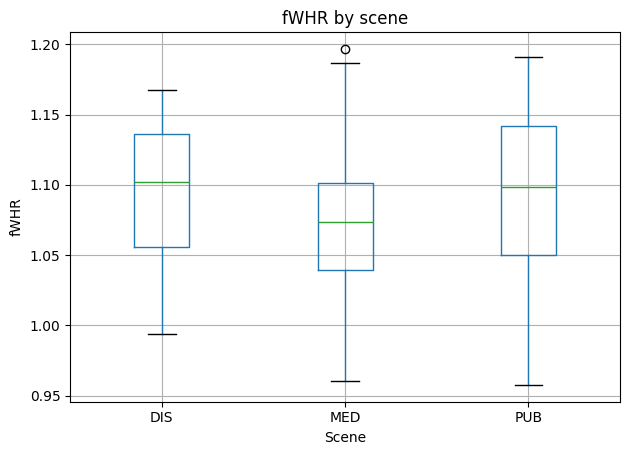

<Figure size 600x400 with 0 Axes>

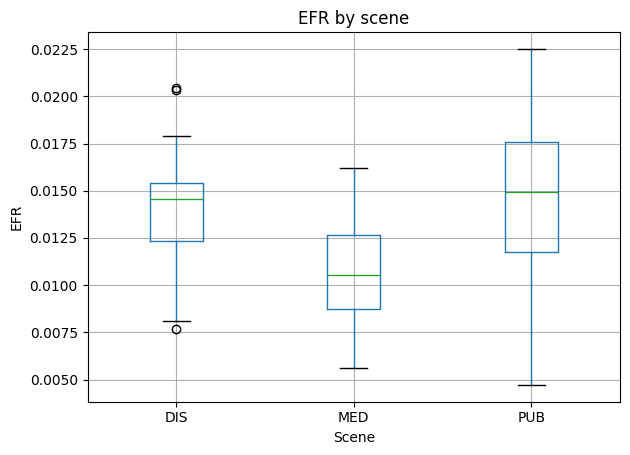

<Figure size 600x400 with 0 Axes>

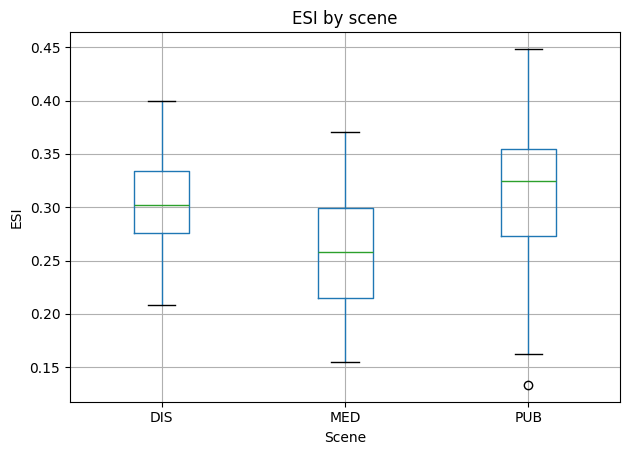

<Figure size 600x400 with 0 Axes>

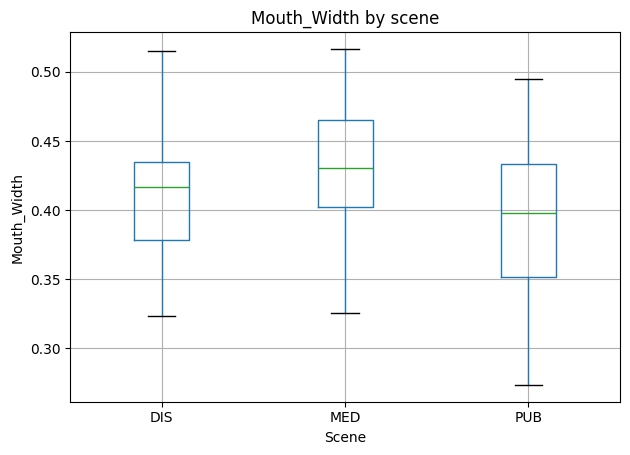

<Figure size 600x400 with 0 Axes>

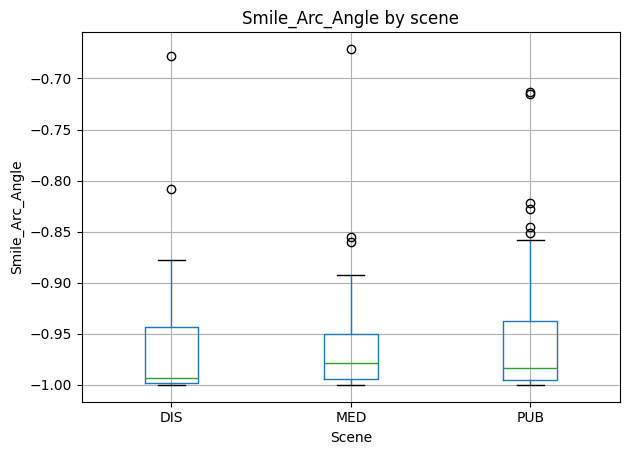

图已保存到： /content/poster_face_analysis/05_pca_projection/figures


In [18]:
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("/content/poster_face_analysis/05_pca_projection/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

features = ["fWHR", "EFR", "ESI", "Mouth_Width", "Smile_Arc_Angle"]

for feature in features:
    plt.figure(figsize=(6, 4))
    result_df.boxplot(column=feature, by="scene")
    plt.title(f"{feature} by scene")
    plt.suptitle("")
    plt.xlabel("Scene")
    plt.ylabel(feature)

    plt.tight_layout()

    png_path = FIG_DIR / f"boxplot_{feature}_by_scene.png"
    pdf_path = FIG_DIR / f"boxplot_{feature}_by_scene.pdf"

    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")

    plt.show()
    plt.close()

print("图已保存到：", FIG_DIR)

In [19]:
import shutil
from google.colab import files

shutil.make_archive(
    "/content/dlib_JP_all_with_features",
    "zip",
    "/content/poster_face_analysis"
)

files.download("/content/dlib_JP_all_with_features.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
import shutil
from google.colab import files

shutil.make_archive(
    "/content/dlib_JP_all_with_features",
    "zip",
    "/content/poster_face_analysis"
)

files.download("/content/dlib_JP_all_with_features.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
from pathlib import Path
import pandas as pd
import numpy as np

FEATURE_DIR = Path("/content/poster_face_analysis/04_features")
FIG_DIR = Path("/content/poster_face_analysis/05_pca_projection/figures")

FEATURE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

features = ["fWHR", "EFR", "ESI", "Mouth_Width", "Smile_Arc_Angle"]

overall_summary = result_df[features].agg(["count", "mean", "std", "min", "max"]).T
overall_summary = overall_summary.reset_index().rename(columns={"index": "feature"})

overall_summary_csv = FEATURE_DIR / "poster_face_features_overall_summary_JP.csv"
overall_summary_excel = FEATURE_DIR / "poster_face_features_overall_summary_JP.xlsx"

overall_summary.to_csv(overall_summary_csv, index=False, encoding="utf-8-sig")
overall_summary.to_excel(overall_summary_excel, index=False)

overall_summary

,feature,count,mean,std,min,max
0,fWHR,101.0,1.085785,0.056018,0.957637,1.196626
1,EFR,101.0,0.012864,0.003884,0.004716,0.022500
2,ESI,101.0,0.288178,0.060349,0.133360,0.448360
3,Mouth_Width,101.0,0.410415,0.052310,0.273537,0.516536
4,Smile_Arc_Angle,101.0,-0.953930,0.070552,-1.000000,-0.671301


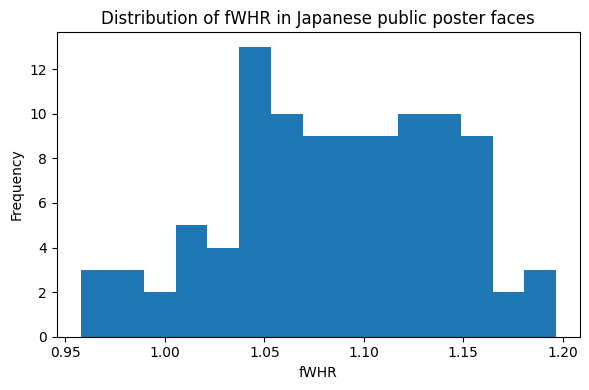

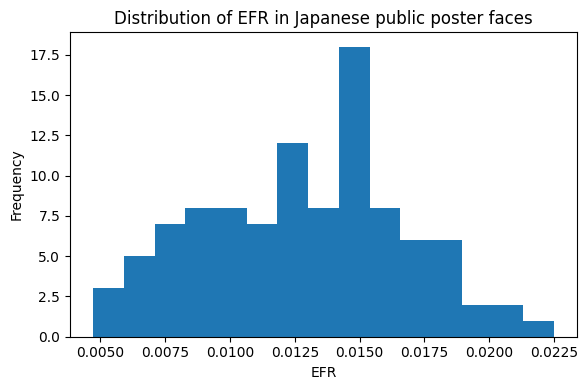

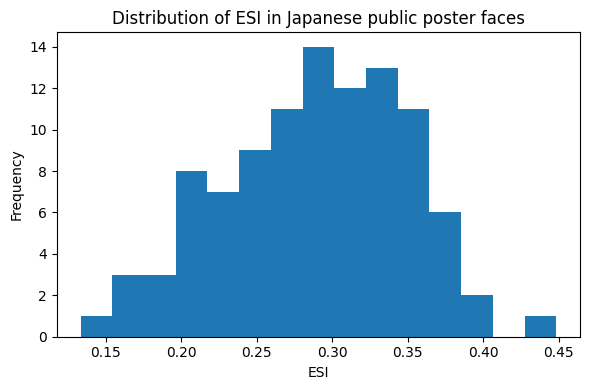

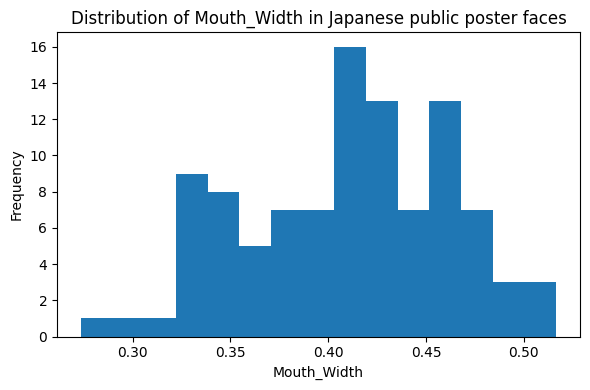

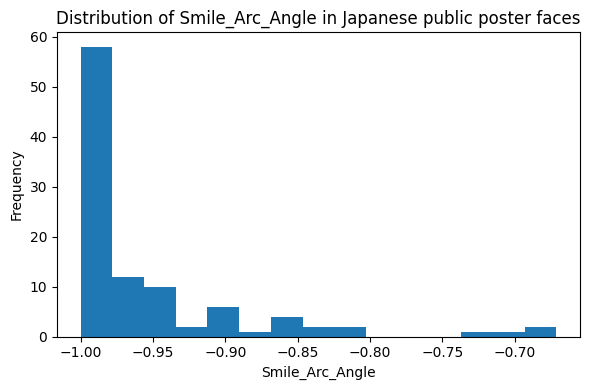

整体分布图已保存到： /content/poster_face_analysis/05_pca_projection/figures


In [21]:
import matplotlib.pyplot as plt

for feature in features:
    plt.figure(figsize=(6, 4))
    plt.hist(result_df[feature].dropna(), bins=15)
    plt.title(f"Distribution of {feature} in Japanese public poster faces")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()

    png_path = FIG_DIR / f"hist_{feature}_JP_public_poster_faces.png"
    pdf_path = FIG_DIR / f"hist_{feature}_JP_public_poster_faces.pdf"

    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close()

print("整体分布图已保存到：", FIG_DIR)

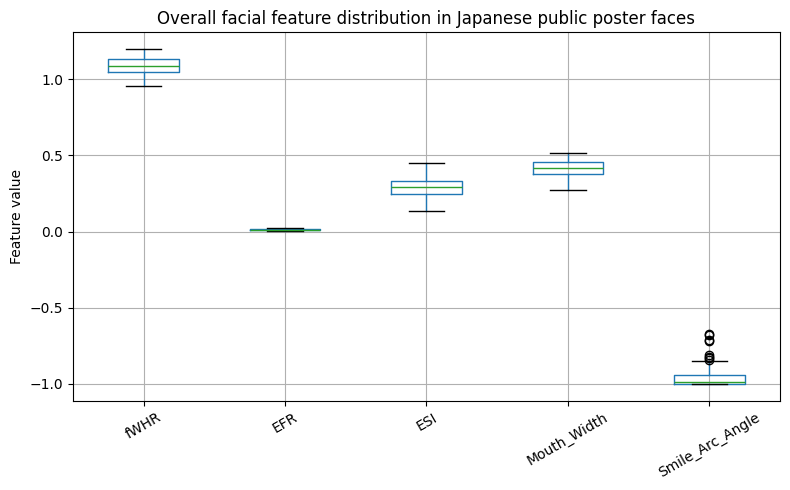

In [22]:
plt.figure(figsize=(8, 5))
result_df[features].boxplot()
plt.title("Overall facial feature distribution in Japanese public poster faces")
plt.ylabel("Feature value")
plt.xticks(rotation=30)
plt.tight_layout()

png_path = FIG_DIR / "boxplot_overall_features_JP_public_poster_faces.png"
pdf_path = FIG_DIR / "boxplot_overall_features_JP_public_poster_faces.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()
plt.close()

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = result_df[features].dropna()
valid_df = result_df.loc[X.index].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_scores = pca.fit_transform(X_scaled)

valid_df["PCA1"] = pca_scores[:, 0]
valid_df["PCA2"] = pca_scores[:, 1]

explained = pca.explained_variance_ratio_

print("Explained variance ratio:")
print("PCA1:", explained[0])
print("PCA2:", explained[1])

pca_output_csv = FEATURE_DIR / "poster_face_pca_scores_JP_public_poster_faces.csv"
valid_df.to_csv(pca_output_csv, index=False, encoding="utf-8-sig")

valid_df.head()

Explained variance ratio:
PCA1: 0.45851975564510195
PCA2: 0.26827527407379553


,poster_id,filename,scene,num_faces_detected,image_width,image_height,fWHR,EFR,ESI,Mouth_Width,Smile_Arc_Angle,PCA1,PCA2
0,JP_DIS_001,JP_DIS_001_face.png,DIS,1,408,516,1.010919,0.012473,0.301296,0.416894,-0.997366,-0.389417,0.103984
1,JP_DIS_002,JP_DIS_002_face.png,DIS,1,490,560,1.141971,0.015676,0.320004,0.406120,-0.995822,0.800581,-1.168308
2,JP_DIS_003,JP_DIS_003_face.png,DIS,1,424,532,1.039812,0.014571,0.307231,0.378006,-0.993162,0.435717,0.021115
3,JP_DIS_004,JP_DIS_004_face.png,DIS,1,364,436,1.038293,0.017894,0.342977,0.444012,-0.999869,0.666271,-0.922615
4,JP_DIS_005face,JP_DIS_005face.png,DIS,1,588,776,1.140407,0.014925,0.323656,0.420203,-0.999973,0.580461,-1.253521


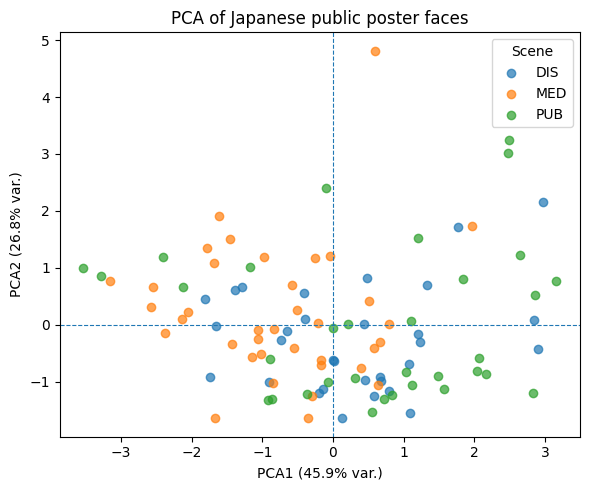

In [24]:
plt.figure(figsize=(6, 5))

for scene, group_df in valid_df.groupby("scene"):
    plt.scatter(group_df["PCA1"], group_df["PCA2"], label=scene, alpha=0.7)

plt.axhline(0, linestyle="--", linewidth=0.8)
plt.axvline(0, linestyle="--", linewidth=0.8)

plt.xlabel(f"PCA1 ({explained[0]*100:.1f}% var.)")
plt.ylabel(f"PCA2 ({explained[1]*100:.1f}% var.)")
plt.title("PCA of Japanese public poster faces")
plt.legend(title="Scene")
plt.tight_layout()

png_path = FIG_DIR / "pca_JP_public_poster_faces_by_scene.png"
pdf_path = FIG_DIR / "pca_JP_public_poster_faces_by_scene.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()
plt.close()

In [25]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PCA1_loading", "PCA2_loading"],
    index=features
).reset_index().rename(columns={"index": "feature"})

loading_csv = FEATURE_DIR / "poster_face_pca_loadings_JP_public_poster_faces.csv"
loading_excel = FEATURE_DIR / "poster_face_pca_loadings_JP_public_poster_faces.xlsx"

loadings.to_csv(loading_csv, index=False, encoding="utf-8-sig")
loadings.to_excel(loading_excel, index=False)

loadings

,feature,PCA1_loading,PCA2_loading
0,fWHR,0.182289,-0.445933
1,EFR,0.570545,-0.324028
2,ESI,0.599778,-0.172028
3,Mouth_Width,-0.463205,-0.399663
4,Smile_Arc_Angle,0.258758,0.711917


In [26]:
import shutil
from google.colab import files

shutil.make_archive(
    "/content/dlib_JP_public_poster_face_analysis",
    "zip",
    "/content/poster_face_analysis"
)

files.download("/content/dlib_JP_public_poster_face_analysis.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path("/content/poster_face_analysis")
FEATURE_DIR = BASE_DIR / "04_features"
FIG_DIR = BASE_DIR / "05_pca_projection" / "figures"

FEATURE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

landmark_csv = FEATURE_DIR / "poster_dlib_landmarks_JP_all.csv"
df = pd.read_csv(landmark_csv)

def get_point(row, idx):
    # dlib index: 0-based; csv: x1/y1 ... x68/y68
    return np.array([row[f"x{idx+1}"], row[f"y{idx+1}"]], dtype=float)

def dist(p1, p2):
    return np.linalg.norm(p1 - p2)

def polygon_area(points):
    x = points[:, 0]
    y = points[:, 1]
    return 0.5 * np.abs(
        np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1))
    )

def angle_cosine(a, b, c):
    ba = a - b
    bc = c - b
    denom = np.linalg.norm(ba) * np.linalg.norm(bc)
    if denom == 0:
        return np.nan
    return np.dot(ba, bc) / denom

def calc_features_extended(row):
    # 基本点
    jaw_left = get_point(row, 0)
    jaw_right = get_point(row, 16)
    chin = get_point(row, 8)

    cheek_left = get_point(row, 1)
    cheek_right = get_point(row, 15)

    brow_left_inner = get_point(row, 21)
    brow_right_inner = get_point(row, 22)
    brow_mid = (brow_left_inner + brow_right_inner) / 2

    mouth_left = get_point(row, 48)
    mouth_right = get_point(row, 54)
    upper_lip_mid = get_point(row, 51)
    lower_lip_mid = get_point(row, 57)
    mouth_center = (upper_lip_mid + lower_lip_mid) / 2

    face_width = dist(jaw_left, jaw_right)
    cheek_width = dist(cheek_left, cheek_right)
    face_height = dist(brow_mid, chin)

    if face_width == 0 or face_height == 0:
        return pd.Series({
            "fWHR": np.nan,
            "EFR": np.nan,
            "ESI": np.nan,
            "Mouth_Width": np.nan,
            "Smile_Arc_Angle": np.nan,
            "mouth_height_ratio": np.nan,
            "smile_index": np.nan,
            "mouth_corner_lift": np.nan,
        })

    # 1. fWHR
    fWHR = cheek_width / face_height

    # 2. EFR
    left_eye_points = np.array([get_point(row, i) for i in range(36, 42)])
    right_eye_points = np.array([get_point(row, i) for i in range(42, 48)])

    left_eye_area = polygon_area(left_eye_points)
    right_eye_area = polygon_area(right_eye_points)

    face_area = face_width * face_height
    EFR = (left_eye_area + right_eye_area) / face_area

    # 3. ESI
    left_eye_width = dist(get_point(row, 36), get_point(row, 39))
    right_eye_width = dist(get_point(row, 42), get_point(row, 45))

    left_eye_height = (
        dist(get_point(row, 37), get_point(row, 41)) +
        dist(get_point(row, 38), get_point(row, 40))
    ) / 2

    right_eye_height = (
        dist(get_point(row, 43), get_point(row, 47)) +
        dist(get_point(row, 44), get_point(row, 46))
    ) / 2

    mean_eye_width = (left_eye_width + right_eye_width) / 2
    mean_eye_height = (left_eye_height + right_eye_height) / 2
    ESI = mean_eye_height / mean_eye_width if mean_eye_width != 0 else np.nan

    # 4. Mouth Width
    mouth_width = dist(mouth_left, mouth_right)
    Mouth_Width = mouth_width / face_width

    # 5. Smile Arc Angle
    Smile_Arc_Angle = angle_cosine(mouth_left, upper_lip_mid, mouth_right)

    # 6. mouth_height_ratio
    mouth_height = dist(upper_lip_mid, lower_lip_mid)
    mouth_height_ratio = mouth_height / face_height

    # 7. smile_index
    # 嘴宽 / 嘴高，越大表示嘴横向展开越明显
    smile_index = mouth_width / mouth_height if mouth_height != 0 else np.nan

    # 8. mouth_corner_lift
    # 图像坐标 y 越小越靠上。
    # 这里用：嘴中心 y - 两嘴角平均 y
    # 数值越大，表示嘴角越靠上，更像上扬。
    mouth_corner_y_mean = (mouth_left[1] + mouth_right[1]) / 2
    mouth_corner_lift = (mouth_center[1] - mouth_corner_y_mean) / face_height

    return pd.Series({
        "fWHR": fWHR,
        "EFR": EFR,
        "ESI": ESI,
        "Mouth_Width": Mouth_Width,
        "Smile_Arc_Angle": Smile_Arc_Angle,
        "mouth_height_ratio": mouth_height_ratio,
        "smile_index": smile_index,
        "mouth_corner_lift": mouth_corner_lift,
    })

feature_df_ext = df.apply(calc_features_extended, axis=1)

result_ext_df = pd.concat([
    df[["poster_id", "filename", "scene", "num_faces_detected", "image_width", "image_height"]],
    feature_df_ext
], axis=1)

output_csv = FEATURE_DIR / "poster_face_features_extended_JP_all.csv"
output_excel = FEATURE_DIR / "poster_face_features_extended_JP_all.xlsx"

result_ext_df.to_csv(output_csv, index=False, encoding="utf-8-sig")
result_ext_df.to_excel(output_excel, index=False)

print("扩展特征表保存完成：")
print(output_csv)
print(output_excel)

result_ext_df.head()

扩展特征表保存完成：
/content/poster_face_analysis/04_features/poster_face_features_extended_JP_all.csv
/content/poster_face_analysis/04_features/poster_face_features_extended_JP_all.xlsx


,poster_id,filename,scene,num_faces_detected,image_width,image_height,fWHR,EFR,ESI,Mouth_Width,Smile_Arc_Angle,mouth_height_ratio,smile_index,mouth_corner_lift
0,JP_DIS_001,JP_DIS_001_face.png,DIS,1,408,516,1.010919,0.012473,0.301296,0.416894,-0.997366,0.112197,3.788409,0.048085
1,JP_DIS_002,JP_DIS_002_face.png,DIS,1,490,560,1.141971,0.015676,0.320004,0.406120,-0.995822,0.109788,4.304196,0.043905
2,JP_DIS_003,JP_DIS_003_face.png,DIS,1,424,532,1.039812,0.014571,0.307231,0.378006,-0.993162,0.106193,3.650250,0.027326
3,JP_DIS_004,JP_DIS_004_face.png,DIS,1,364,436,1.038293,0.017894,0.342977,0.444012,-0.999869,0.150953,3.023170,0.081010
4,JP_DIS_005face,JP_DIS_005face.png,DIS,1,588,776,1.140407,0.014925,0.323656,0.420203,-0.999973,0.168410,2.908814,0.084075


In [28]:
new_features = [
    "Mouth_Width",
    "Smile_Arc_Angle",
    "mouth_height_ratio",
    "smile_index",
    "mouth_corner_lift"
]

mouth_summary = result_ext_df[new_features].agg(["count", "mean", "std", "min", "max"]).T
mouth_summary = mouth_summary.reset_index().rename(columns={"index": "feature"})

mouth_summary_csv = FEATURE_DIR / "mouth_feature_summary_JP_public_poster_faces.csv"
mouth_summary_excel = FEATURE_DIR / "mouth_feature_summary_JP_public_poster_faces.xlsx"

mouth_summary.to_csv(mouth_summary_csv, index=False, encoding="utf-8-sig")
mouth_summary.to_excel(mouth_summary_excel, index=False)

mouth_summary

,feature,count,mean,std,min,max
0,Mouth_Width,101.0,0.410415,0.052310,0.273537,0.516536
1,Smile_Arc_Angle,101.0,-0.953930,0.070552,-1.000000,-0.671301
2,mouth_height_ratio,101.0,0.156988,0.037012,0.063467,0.238661
3,smile_index,101.0,2.995956,0.719222,1.971992,6.618761
4,mouth_corner_lift,101.0,0.056044,0.027582,-0.022601,0.115406


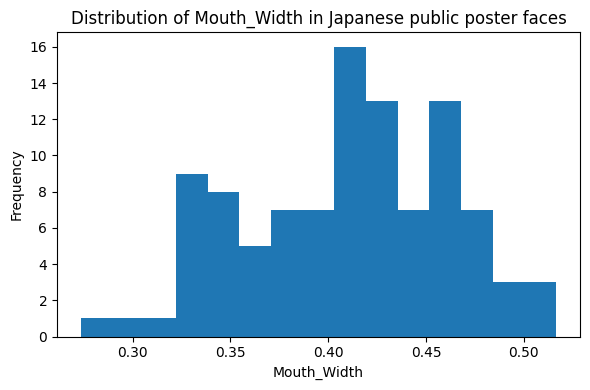

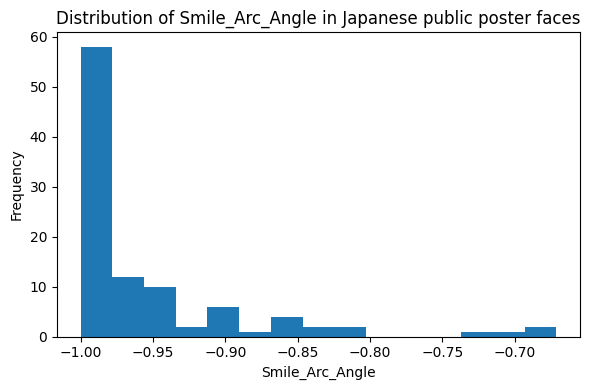

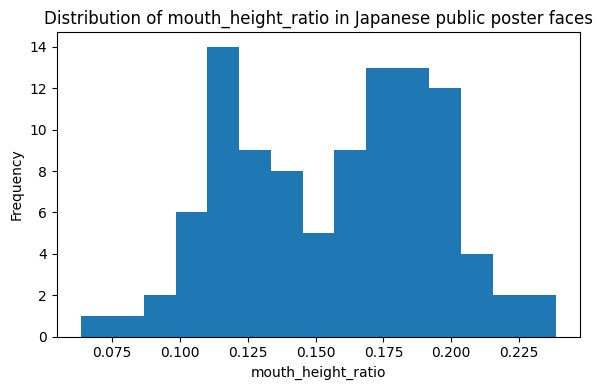

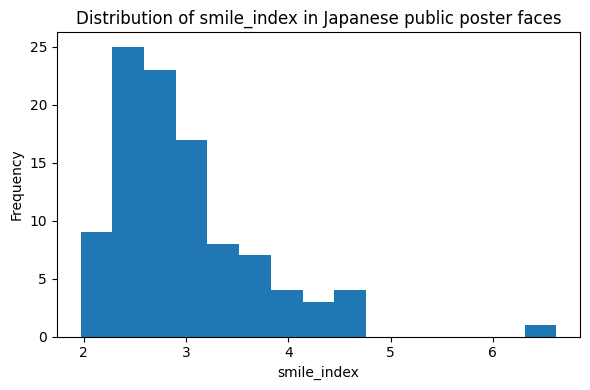

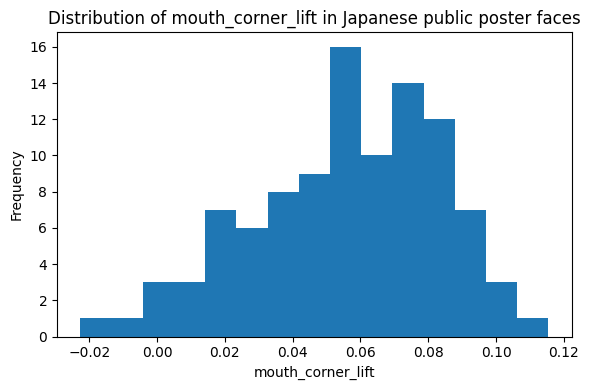

新增嘴部指标分布图已保存


In [29]:
import matplotlib.pyplot as plt

for feature in new_features:
    plt.figure(figsize=(6, 4))
    plt.hist(result_ext_df[feature].dropna(), bins=15)
    plt.title(f"Distribution of {feature} in Japanese public poster faces")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()

    png_path = FIG_DIR / f"hist_{feature}_JP_public_poster_faces.png"
    pdf_path = FIG_DIR / f"hist_{feature}_JP_public_poster_faces.pdf"

    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close()

print("新增嘴部指标分布图已保存")

<Figure size 600x400 with 0 Axes>

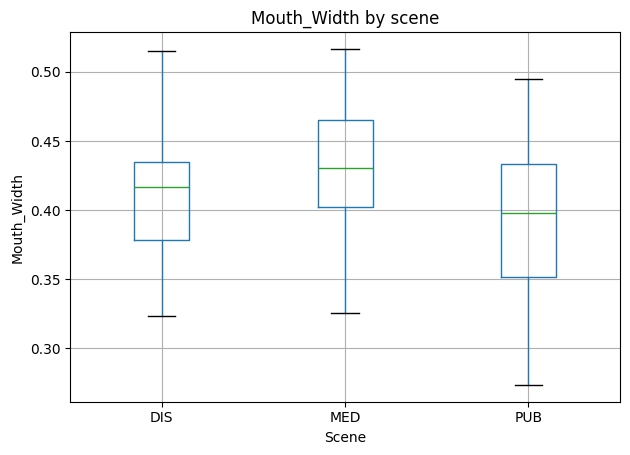

<Figure size 600x400 with 0 Axes>

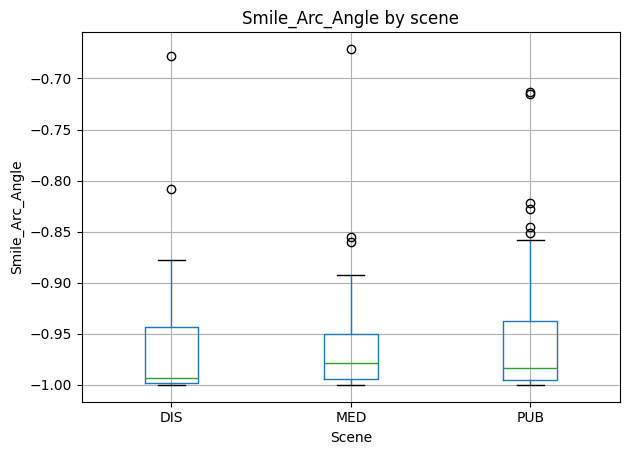

<Figure size 600x400 with 0 Axes>

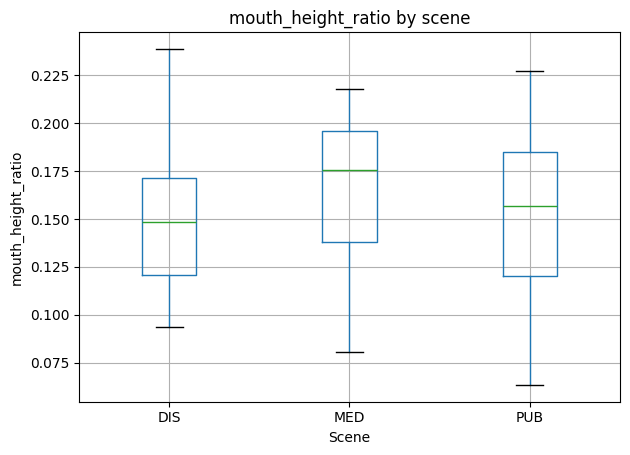

<Figure size 600x400 with 0 Axes>

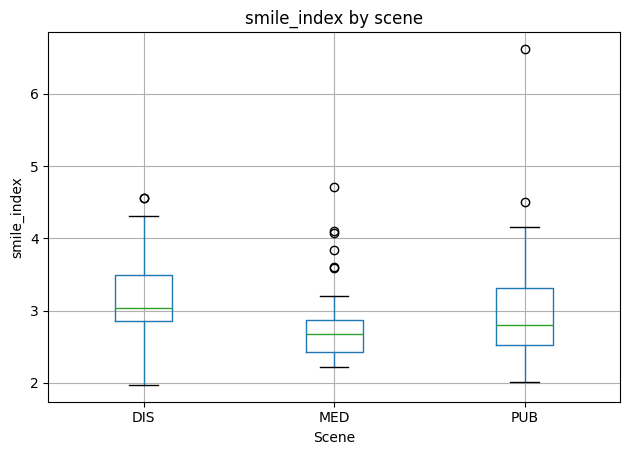

<Figure size 600x400 with 0 Axes>

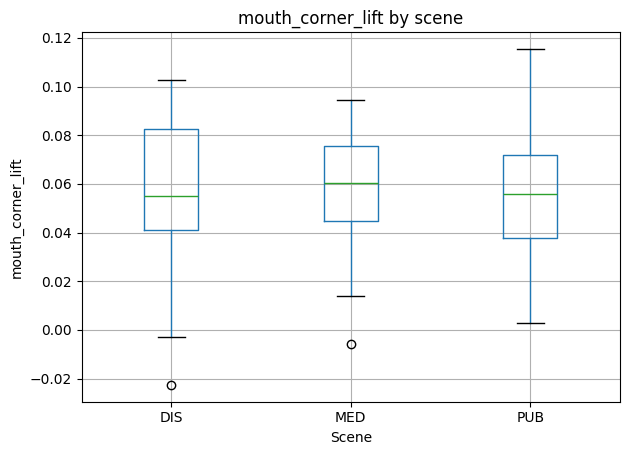

新增嘴部指标 by scene 箱线图已保存


In [30]:
for feature in new_features:
    plt.figure(figsize=(6, 4))
    result_ext_df.boxplot(column=feature, by="scene")
    plt.title(f"{feature} by scene")
    plt.suptitle("")
    plt.xlabel("Scene")
    plt.ylabel(feature)
    plt.tight_layout()

    png_path = FIG_DIR / f"boxplot_{feature}_by_scene.png"
    pdf_path = FIG_DIR / f"boxplot_{feature}_by_scene.pdf"

    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close()

print("新增嘴部指标 by scene 箱线图已保存")

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_features_ext = [
    "fWHR",
    "EFR",
    "ESI",
    "Mouth_Width",
    "mouth_height_ratio",
    "smile_index",
    "mouth_corner_lift"
]

X = result_ext_df[pca_features_ext].dropna()
valid_ext_df = result_ext_df.loc[X.index].copy()

scaler_ext = StandardScaler()
X_scaled = scaler_ext.fit_transform(X)

pca_ext = PCA(n_components=2)
pca_scores_ext = pca_ext.fit_transform(X_scaled)

valid_ext_df["PCA1_ext"] = pca_scores_ext[:, 0]
valid_ext_df["PCA2_ext"] = pca_scores_ext[:, 1]

explained_ext = pca_ext.explained_variance_ratio_

print("Explained variance ratio:")
print("PCA1_ext:", explained_ext[0])
print("PCA2_ext:", explained_ext[1])
print("Total:", explained_ext[0] + explained_ext[1])

pca_scores_csv = FEATURE_DIR / "poster_face_pca_scores_extended_JP_public_poster_faces.csv"
valid_ext_df.to_csv(pca_scores_csv, index=False, encoding="utf-8-sig")

valid_ext_df.head()

Explained variance ratio:
PCA1_ext: 0.46249264847422017
PCA2_ext: 0.20496537716445565
Total: 0.6674580256386758


,poster_id,filename,scene,num_faces_detected,image_width,image_height,fWHR,EFR,ESI,Mouth_Width,Smile_Arc_Angle,mouth_height_ratio,smile_index,mouth_corner_lift,PCA1_ext,PCA2_ext
0,JP_DIS_001,JP_DIS_001_face.png,DIS,1,408,516,1.010919,0.012473,0.301296,0.416894,-0.997366,0.112197,3.788409,0.048085,-0.953362,-0.996539
1,JP_DIS_002,JP_DIS_002_face.png,DIS,1,490,560,1.141971,0.015676,0.320004,0.406120,-0.995822,0.109788,4.304196,0.043905,-2.055301,0.480481
2,JP_DIS_003,JP_DIS_003_face.png,DIS,1,424,532,1.039812,0.014571,0.307231,0.378006,-0.993162,0.106193,3.650250,0.027326,-1.856499,-1.042693
3,JP_DIS_004,JP_DIS_004_face.png,DIS,1,364,436,1.038293,0.017894,0.342977,0.444012,-0.999869,0.150953,3.023170,0.081010,-0.293732,1.217463
4,JP_DIS_005face,JP_DIS_005face.png,DIS,1,588,776,1.140407,0.014925,0.323656,0.420203,-0.999973,0.168410,2.908814,0.084075,0.100737,1.593367


In [32]:
loadings_ext = pd.DataFrame(
    pca_ext.components_.T,
    columns=["PCA1_ext_loading", "PCA2_ext_loading"],
    index=pca_features_ext
).reset_index().rename(columns={"index": "feature"})

loading_ext_csv = FEATURE_DIR / "poster_face_pca_loadings_extended_JP_public_poster_faces.csv"
loading_ext_excel = FEATURE_DIR / "poster_face_pca_loadings_extended_JP_public_poster_faces.xlsx"

loadings_ext.to_csv(loading_ext_csv, index=False, encoding="utf-8-sig")
loadings_ext.to_excel(loading_ext_excel, index=False)

loadings_ext

,feature,PCA1_ext_loading,PCA2_ext_loading
0,fWHR,-0.097075,0.461484
1,EFR,-0.385878,0.516636
2,ESI,-0.422869,0.386041
3,Mouth_Width,0.409811,0.249927
4,mouth_height_ratio,0.486171,0.224287
5,smile_index,-0.344839,-0.017774
6,mouth_corner_lift,0.373678,0.507945


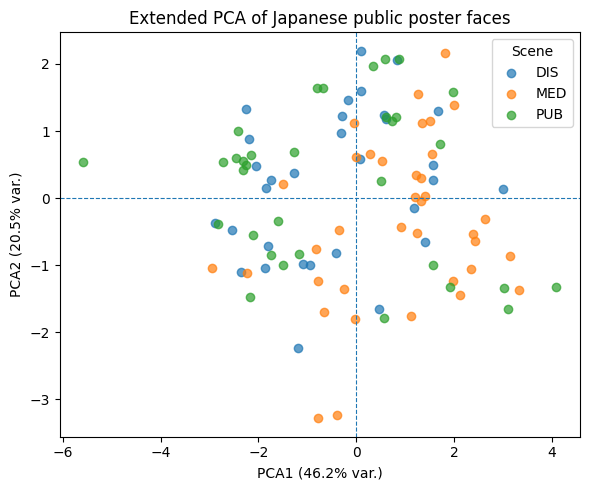

In [33]:
plt.figure(figsize=(6, 5))

for scene, group_df in valid_ext_df.groupby("scene"):
    plt.scatter(group_df["PCA1_ext"], group_df["PCA2_ext"], label=scene, alpha=0.7)

plt.axhline(0, linestyle="--", linewidth=0.8)
plt.axvline(0, linestyle="--", linewidth=0.8)

plt.xlabel(f"PCA1 ({explained_ext[0]*100:.1f}% var.)")
plt.ylabel(f"PCA2 ({explained_ext[1]*100:.1f}% var.)")
plt.title("Extended PCA of Japanese public poster faces")
plt.legend(title="Scene")
plt.tight_layout()

png_path = FIG_DIR / "pca_extended_JP_public_poster_faces_by_scene.png"
pdf_path = FIG_DIR / "pca_extended_JP_public_poster_faces_by_scene.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()
plt.close()

In [34]:
import shutil
from google.colab import files

shutil.make_archive(
    "/content/dlib_JP_public_poster_face_analysis_extended",
    "zip",
    "/content/poster_face_analysis"
)

files.download("/content/dlib_JP_public_poster_face_analysis_extended.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>